# Supplementary McFaline example perturbation profiles

Reproduces additional McFaline example response profiles for seen and unseen perturbation settings.


In [1]:
# Set to True to write image files to figures/supplement/output/.
SAVE_FIGURES = False

## Example perturbation profiles


Seen perturbation example
TranScouter: 0 wrong-direction DEG(s)
  None
scGen: 8 wrong-direction DEG(s)
  SCD, CDC42EP3, RNF213, LTBP1, DBN1, FADS2, PKM, TTC3
Average: 6 wrong-direction DEG(s)
  MKX, SCD, TSC22D1, MPP7, FADS2, TTC3


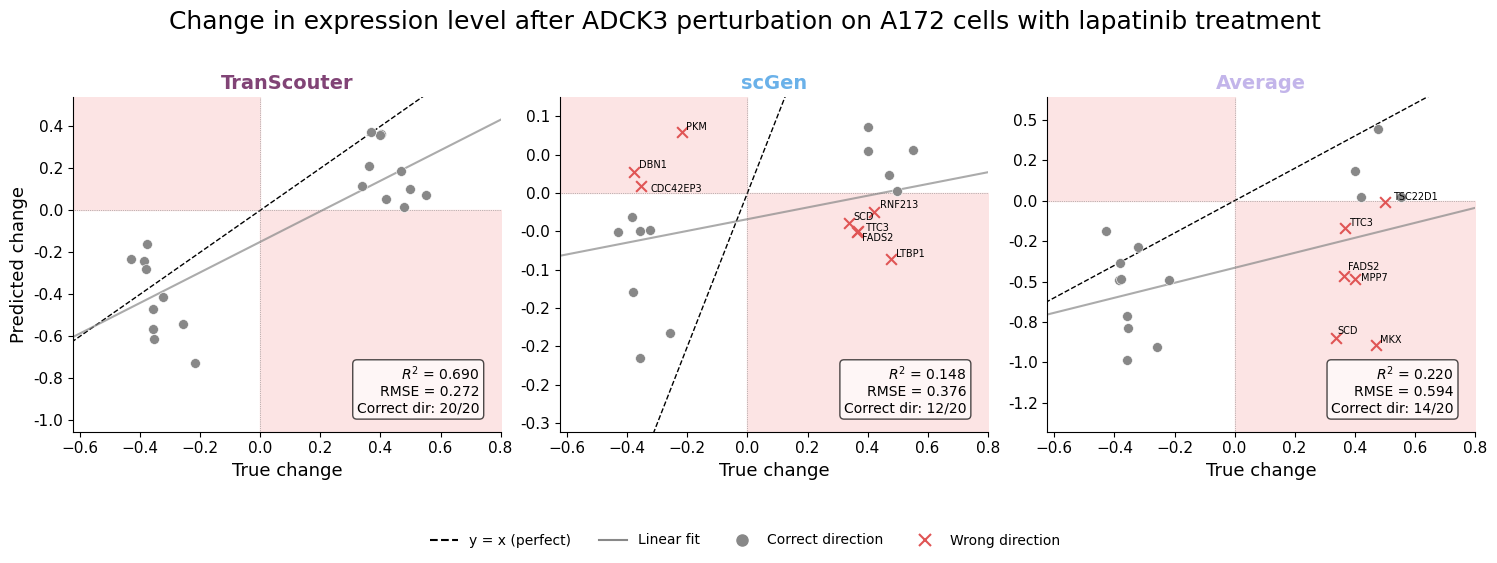

Unseen perturbation example
TranScouter: 1 wrong-direction DEG(s)
  SAMD4A
Correlation: 16 wrong-direction DEG(s)
  HS3ST3A1, CTSD, WDPCP, CD63, WNK1, CALR, SH2B3, NUMB, TMBIM6, XRCC6, DNAJC5, PAM, HIP1, SAMD4A, NUCB2, UBAP2
Average: 9 wrong-direction DEG(s)
  HS3ST3A1, CTSD, WDPCP, WNK1, SH2B3, NUMB, DNAJC5, HIP1, SAMD4A


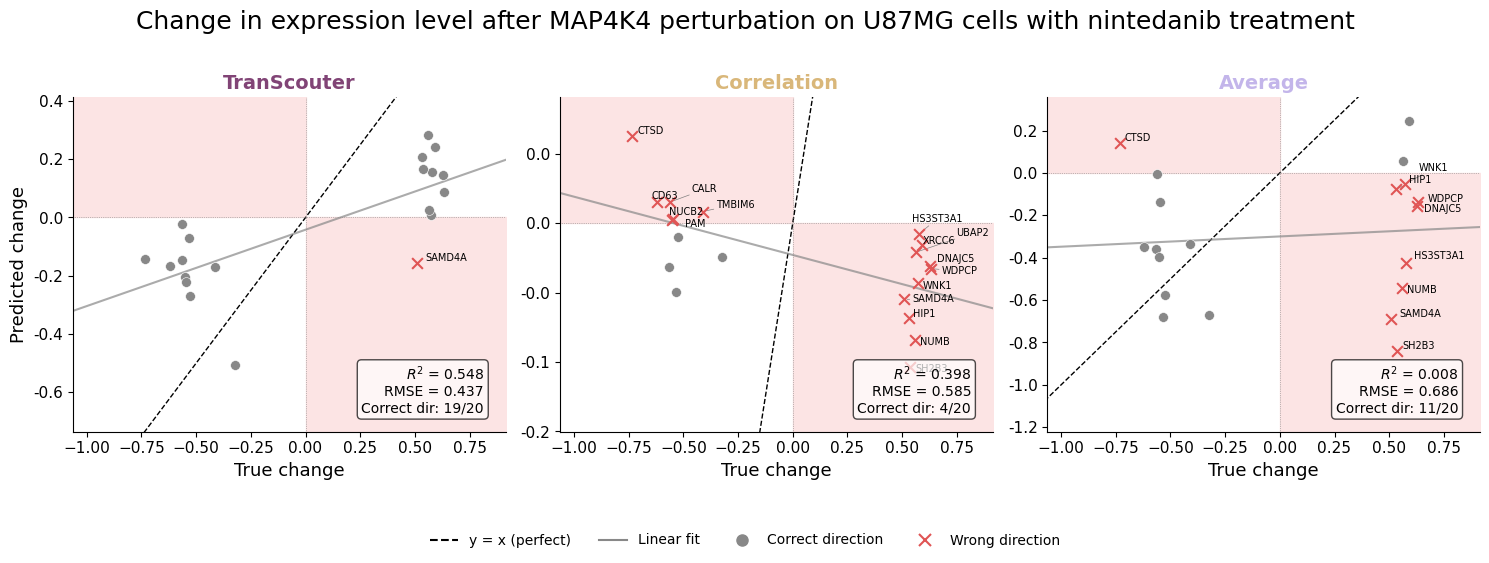

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text
import os
import scanpy as sc
from pathlib import Path
ROOT = Path.cwd().resolve()
while not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()) and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()):
    raise RuntimeError("Run this notebook from inside the TranScouter repository")
os.chdir(ROOT)
Path("figures/main/output").mkdir(parents=True, exist_ok=True)
Path("figures/supplement/output").mkdir(parents=True, exist_ok=True)

# fmt: off
SCENARIOS = {
    "seen": {
        "label": "Seen perturbation example",
        "results_path": "results/collected/mcfaline/seen_pred_results.pkl",
        "cov_pert": "a172+lapatinib_ADCK3",
        "save_prefix": "figures/supplement/output/SeenPerturb_Examp",
        "method_keys": [("TranScouter", "TranScouter"), ("scGen", "scGen"), ("Average", "Avg")],
    },
    "unseen": {
        "label": "Unseen perturbation example",
        "results_path": "results/collected/mcfaline/unseen_pred_results.pkl",
        "cov_pert": "u87mg+nintedanib_MAP4K4",
        "save_prefix": "figures/supplement/output/UnseenPerturb_Examp",
        "method_keys": [("TranScouter", "TranScouter"), ("Correlation", "Correlation"), ("Average", "Avg")],
    },
}

method_colors = {
    "TranScouter": "#814476",
    "Average":     "#c3b5ea",
    "scGen":       "#6ab1e9",
    "trVAE":       "#50acad",
    "Correlation": "#d9b77a",
    "CellOracle":  "#c98f8f",
}
# fmt: on

adata = sc.read_h5ad("data/mcfaline/processed/mcfaline.h5ad")
top_degs_names = adata.uns["top_degs_names"]


def safe_r2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    x = x[keep]
    y = y[keep]
    if x.size < 2 or np.all(x == x[0]) or np.all(y == y[0]):
        return np.nan
    return pearsonr(x, y)[0] ** 2


def print_wrong_direction_genes(method, wrong_genes):
    print(f"{method}: {len(wrong_genes)} wrong-direction DEG(s)")
    if len(wrong_genes):
        print("  " + ", ".join(wrong_genes))
    else:
        print("  None")


def plot_example(cfg):
    print(cfg["label"])
    with open(cfg["results_path"], "rb") as f:
        results = pickle.load(f)

    cov_pert = cfg["cov_pert"]
    cov, pert = cov_pert.split("_")
    celltype, treatment = cov.split("+")
    cov_ctrl = f"{cov}_control"
    degs = top_degs_names[cov_pert]

    ctrl = results["Ctrl"].loc[cov_ctrl, degs]
    true = results["True"].loc[cov_pert, degs] - ctrl
    methods = {
        label: results[result_key].loc[cov_pert, degs] - ctrl
        for label, result_key in cfg["method_keys"]
    }
    colors = {name: method_colors[name] for name in methods}

    plt.rcParams.update({
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
    })

    fig, axes = plt.subplots(1, len(methods), figsize=(15, 5))
    axes = np.atleast_1d(axes)
    fig.suptitle(
        f"Change in expression level after {pert} perturbation on "
        f"{celltype.upper()} cells with {treatment} treatment",
        fontsize=18, y=1.02,
    )

    corner_pad = 1.45
    x_min = true.values.min() * corner_pad
    x_max = true.values.max() * corner_pad
    neutral = "#888888"

    for ax, (method, pred) in zip(axes, methods.items()):
        color = colors[method]
        correct = np.sign(pred.values) == np.sign(true.values)

        y_min = pred.values.min() * corner_pad
        y_max = pred.values.max() * corner_pad
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

        ax.fill_between([x_min, 0], 0, y_max, color="#fce4e4", zorder=0)
        ax.fill_between([0, x_max], y_min, 0, color="#fce4e4", zorder=0)

        diag_lim = max(abs(x_min), abs(x_max), abs(y_min), abs(y_max))
        ax.plot([-diag_lim, diag_lim], [-diag_lim, diag_lim], "k--", linewidth=1, zorder=1)
        lr = LinearRegression().fit(true.values.reshape(-1, 1), pred.values)
        x_fit = np.linspace(x_min, x_max, 100)
        ax.plot(x_fit, lr.predict(x_fit.reshape(-1, 1)), color=neutral, linewidth=1.5, alpha=0.7, zorder=2)

        ax.scatter(true[correct], pred[correct], color=neutral, marker="o", s=50, edgecolors="white", linewidths=0.4, zorder=3)
        ax.scatter(true[~correct], pred[~correct], color="#e05555", marker="x", s=60, linewidths=1.5, zorder=3)

        wrong_genes = np.array(degs)[~correct]
        print_wrong_direction_genes(method, wrong_genes)
        if len(wrong_genes):
            texts = [ax.text(true[gene], pred[gene], gene, fontsize=7) for gene in wrong_genes]
            adjust_text(
                texts, ax=ax,
                x=true[wrong_genes].values, y=pred[wrong_genes].values,
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
            )

        r2 = safe_r2(true.values, pred.values)
        rmse = np.sqrt(mean_squared_error(true.values, pred.values))
        n_correct = correct.sum()
        ax.text(
            0.95, 0.05,
            f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}\nCorrect dir: {n_correct}/{len(degs)}",
            transform=ax.transAxes, fontsize=10, va="bottom", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
        )

        ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
        ax.axvline(0, color="gray", linewidth=0.5, linestyle=":")
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}"))
        ax.set_xlabel("True change")
        ax.set_ylabel("Predicted change" if ax == axes[0] else "")
        ax.set_title(method, color=color, fontweight="bold")

    shared_handles = [
        plt.Line2D([0], [0], linestyle="--", color="black", label="y = x (perfect)"),
        plt.Line2D([0], [0], color=neutral, linewidth=1.5, label="Linear fit"),
        plt.Line2D([0], [0], color=neutral, marker="o", markersize=8,
                   linestyle="none", label="Correct direction"),
        plt.Line2D([0], [0], color="#e05555", marker="x", markersize=8,
                   linestyle="none", markeredgewidth=1.5, label="Wrong direction"),
    ]

    fig.legend(
        handles=shared_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=len(shared_handles),
        fontsize=10,
        frameon=False,
    )

    plt.tight_layout(rect=(0, 0.05, 1, 1))
    filename = f"{cfg['save_prefix']}_{pert}.png"
    if globals().get("SAVE_FIGURES", False):
        fig.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"Saved: {filename}")
    plt.show()


for cfg in SCENARIOS.values():
    plot_example(cfg)